In [8]:
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
import pandas as pd

In [3]:
CAMELS_UY_6_dir = Path("../data/time_series/CAMELS_UY_6.nc")

In [5]:
CAMELS_UY_6 = xr.open_dataset(CAMELS_UY_6_dir)
CAMELS_UY_6

<xarray.Dataset> Size: 498kB
Dimensions:             (date: 11322)
Coordinates:
  * date                (date) datetime64[ns] 91kB 1989-01-01 ... 2019-12-31
Data variables:
    tmin_C              (date) float32 45kB ...
    tmax_C              (date) float32 45kB ...
    srad_W_m2           (date) float32 45kB ...
    prcp_mm_day         (date) float32 45kB ...
    QObs_mm_d           (date) float64 91kB ...
    prcp_gauge_mm_day   (date) float32 45kB ...
    prcp_mswep_mm_day   (date) float32 45kB ...
    prcp_chirps_mm_day  (date) float32 45kB ...
Attributes:
    precip_update:  Gauge, MSWEP and CHIRPS added where available

In [9]:
start_date = pd.Timestamp("1989-10-01")
end_date = pd.Timestamp("1990-09-30")

In [12]:
CAMELS_UY_6 = CAMELS_UY_6.sel(date=slice(start_date, end_date))
CAMELS_UY_6

<xarray.Dataset> Size: 16kB
Dimensions:             (date: 365)
Coordinates:
  * date                (date) datetime64[ns] 3kB 1989-10-01 ... 1990-09-30
Data variables:
    tmin_C              (date) float32 1kB ...
    tmax_C              (date) float32 1kB ...
    srad_W_m2           (date) float32 1kB ...
    prcp_mm_day         (date) float32 1kB ...
    QObs_mm_d           (date) float64 3kB ...
    prcp_gauge_mm_day   (date) float32 1kB ...
    prcp_mswep_mm_day   (date) float32 1kB ...
    prcp_chirps_mm_day  (date) float32 1kB ...
Attributes:
    precip_update:  Gauge, MSWEP and CHIRPS added where available

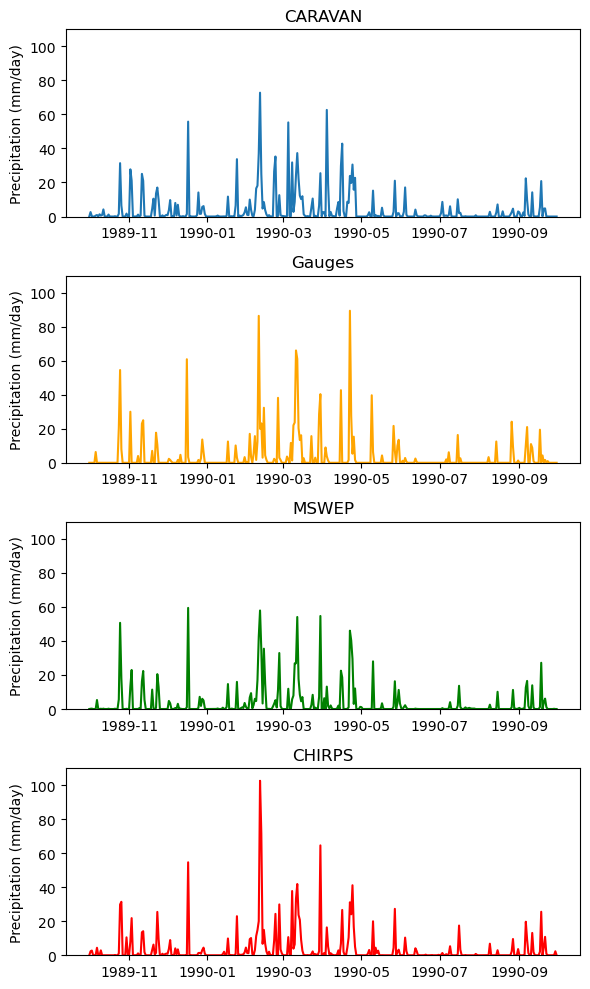

In [25]:
fig, ax = plt.subplots(4,1,figsize=(6, 10))

ax[0].plot(CAMELS_UY_6.date, CAMELS_UY_6.prcp_mm_day, label="CARAVAN")
ax[0].set_title("CARAVAN")
ax[0].set_ylabel("Precipitation (mm/day)")
ax[0].set_ylim(0,110)

ax[1].plot(CAMELS_UY_6.date, CAMELS_UY_6.prcp_gauge_mm_day, label="Gauges", color="orange")
ax[1].set_title("Gauges")
ax[1].set_ylabel("Precipitation (mm/day)")
ax[1].set_ylim(0,110)

ax[2].plot(CAMELS_UY_6.date, CAMELS_UY_6.prcp_mswep_mm_day, label="MSWEP", color="green")
ax[2].set_title("MSWEP")
ax[2].set_ylabel("Precipitation (mm/day)")
ax[2].set_ylim(0,110)

ax[3].plot(CAMELS_UY_6.date, CAMELS_UY_6.prcp_chirps_mm_day, label="CHIRPS", color="red")
ax[3].set_title("CHIRPS")
ax[3].set_ylabel("Precipitation (mm/day)")
ax[3].set_ylim(0,110)

plt.tight_layout()
plt.show()
